In [1]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings
using DataFrames
using GLM # for linear regression

using Revise # automatically sync src updates ----> suuuuuper important for development
using SkyrmionTunneling
const ST = SkyrmionTunneling # alias for easier referencing

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`
[ Info: Precompiling SkyrmionTunneling [51d433a5-d9a2-4638-a6de-06b0503db32e] (cache misses: include_dependency fsize change (2), wrong source (2))


SkyrmionTunneling

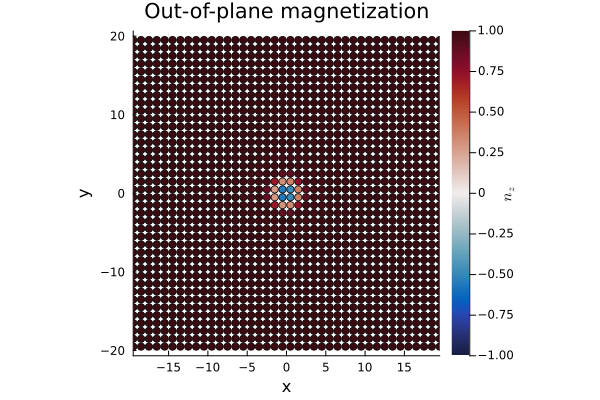

total charge Q = 0.6128570561882338

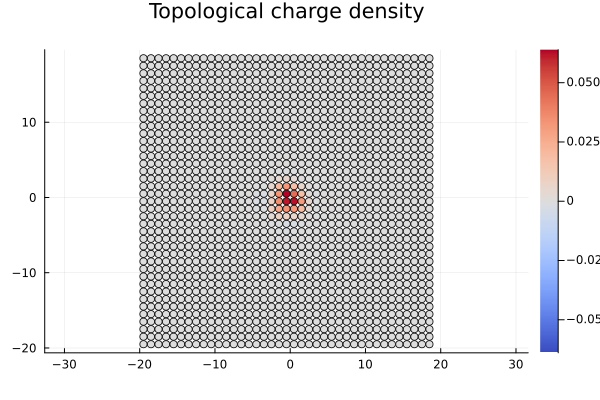

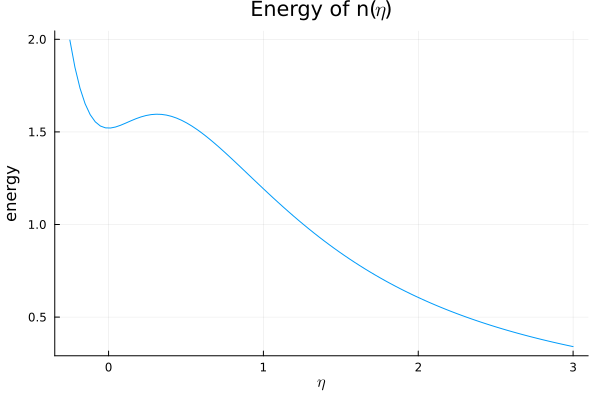

Imaginary part = 3.5754165638429266e-5
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


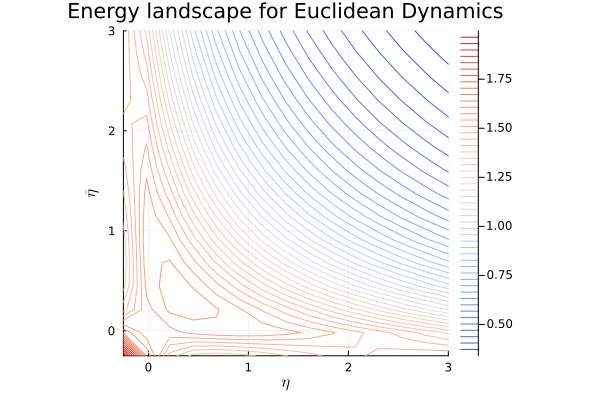

The saddle point is at -0.000639698320119896 + 2.5381484743858673e-5im
The instantonic trajectory passes through the point 
 x = 0.04822324814062389

Progress:   1%|▍                                        |  ETA: 0:00:11

 + 1.4471746683012888e-5im
 y = -0.011258555489606357 - 2.390743955917381e-5im
sanity check : |H_inst-H0| = 1.5234227169063774e-11
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:13


imaginary = 0.0022463821753797597


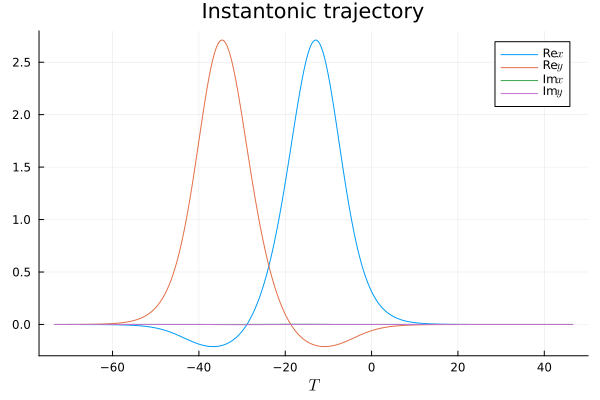

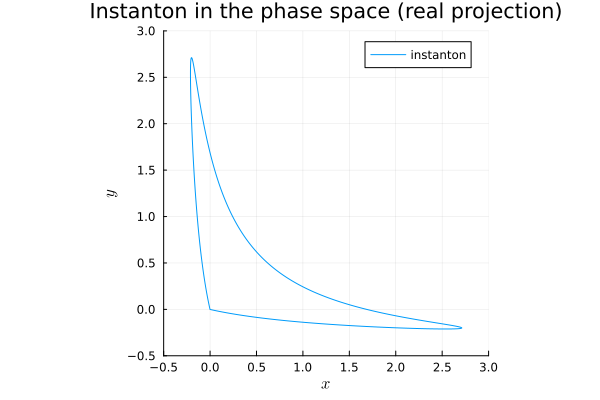

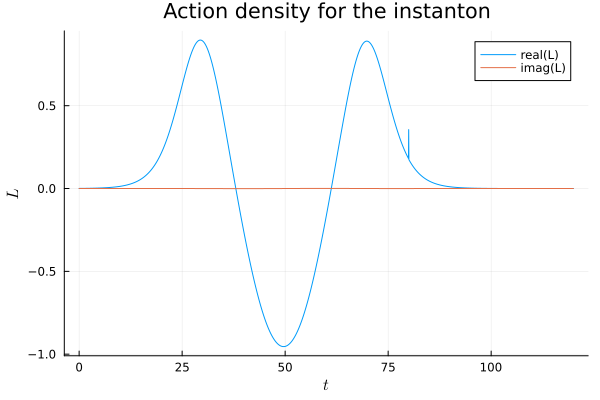


Total action = 7.725116318608425 - 2.5669978585551176e-5im


(7.725116318608425 - 2.5669978585551176e-5im, ComplexF64[-0.0006800020662822105 + 2.6592158324568244e-5im -0.0006805942576841565 + 2.6591996364366555e-5im … -0.0006408165814994639 + 2.6582832946731053e-5im -0.0006408440743969294 + 2.6582541132702345e-5im; -0.00046025465619416075 - 2.6557057685448876e-5im -0.0004576136985164769 - 2.6556382717511407e-5im … -0.0006334082553437032 - 2.6513974946377646e-5im -0.000633311625535647 - 2.6512667837894296e-5im])

In [2]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02
B_avg = 0.22;	B = ST.uniform_B(B_avg,lattice)

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system = System(params,lattice,boundary)

n_Sk = ST.skyrmion(system, annealing=true, LLG_relax=false, show_result=true, N_steps=10000)
coord = LambdaCoordinate(ST.w_project(n_Sk))

up, vp = ST.uv(n_Sk)
um, vm = ST.uv(ST.ferromagnetic(lattice))

coord = EtaCoordinate(up,um,vp,vm)
ST.show_double_well(system, coord,xmin=-0.25, xmax=3.0)
savefig("FM_inst.png")
ST.show_energy_contours(system, coord,xmin=-0.25, xmax=3.0, levels = 50)
savefig("")

S_inst, sol = ST.instanton(system,coord, x_init = 0.0, direction_guess=[0.05, 0.00], T_backward=80.0, T_forward=40.0, dt=0.05, show_action=true, xlims=(-0.5,3))